In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [7]:
filenames = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

headers = []
images = []

for filename in filenames:
    with fits.open(filename) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        
        headers.append(header)
        images.append(data)

print("Number of images loaded:", len(images))
print("Shape of first image:", images[0].shape)

Number of images loaded: 5
Shape of first image: (1040, 1392)


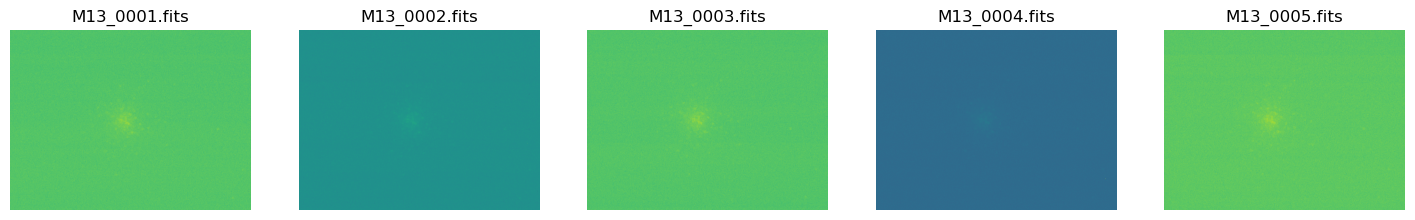

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i in range(5):
    axes[i].imshow(images[i], origin="lower")
    axes[i].set_title(filenames[i])
    axes[i].axis("off")

plt.show()

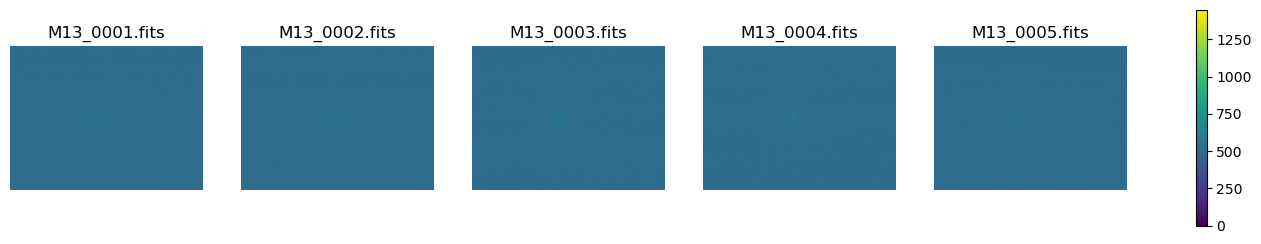

In [9]:
vmin = min(np.min(img) for img in images)
vmax = max(np.max(img) for img in images)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i in range(5):
    im = axes[i].imshow(images[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(filenames[i])
    axes[i].axis("off")

fig.colorbar(im, ax=axes, shrink=0.7)
plt.show()

In [10]:
#Differences: When each image uses its automatic color scale, the images look brighter and the cluster is easier to see in some frames. However, the colors are not directly comparable because each plot is scaled separately.

#When I used the same vmin and vmax for all five images, the images became easier to compare because the same color means the same pixel intensity in every subplot. This makes the faint star/cluster harder to see, but it shows that the images have similar overall background levels.

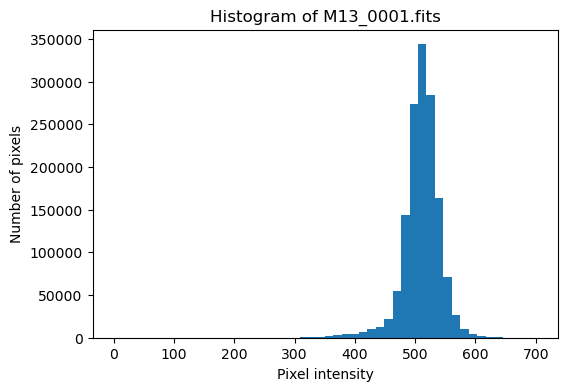

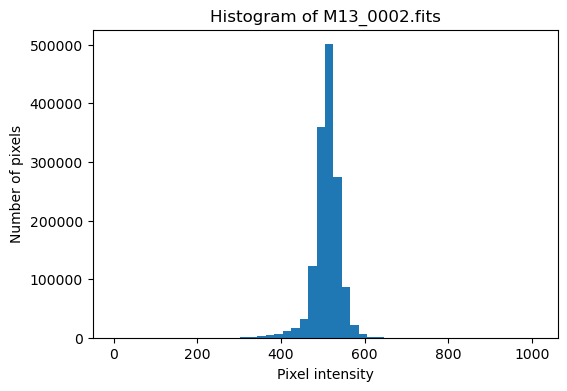

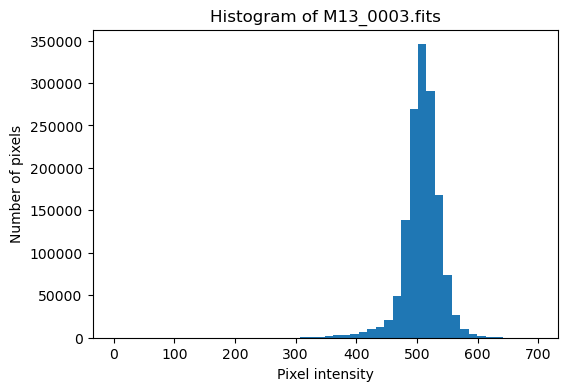

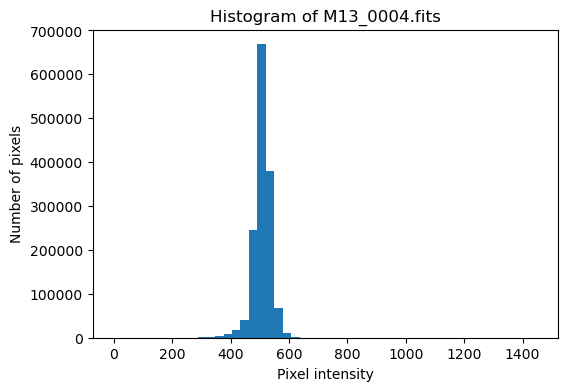

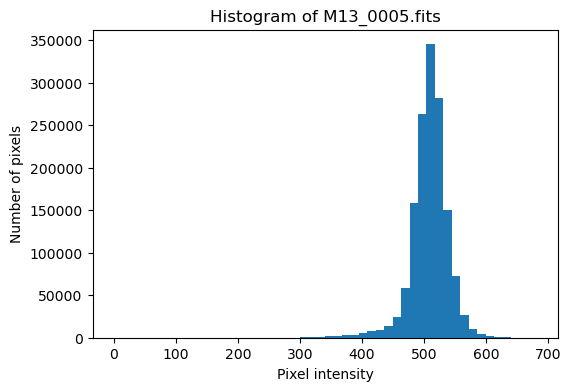

In [11]:
#3.3
for i, img in enumerate(images):
    plt.figure(figsize=(6, 4))
    plt.hist(img.ravel(), bins=50)
    plt.xlabel("Pixel intensity")
    plt.ylabel("Number of pixels")
    plt.title(f"Histogram of {filenames[i]}")
    plt.show()

In [13]:
#mean and medians
for i, img in enumerate(images):
    print(filenames[i])
    print("Mean pixel intensity:", np.mean(img))
    print("Median pixel intensity:", np.median(img))
    print()

M13_0001.fits
Mean pixel intensity: 510.4706668600796
Median pixel intensity: 512.0

M13_0002.fits
Mean pixel intensity: 509.7460150033157
Median pixel intensity: 511.0

M13_0003.fits
Mean pixel intensity: 508.0498729000884
Median pixel intensity: 510.0

M13_0004.fits
Mean pixel intensity: 507.90583554376656
Median pixel intensity: 509.0

M13_0005.fits
Mean pixel intensity: 508.7919920148099
Median pixel intensity: 510.0



In [14]:
#(a) x-axis shows the pixel intensity values in the FITS image. y-axis shows the number of pixels that have intensities in each range.

#(b) bins=50 means the pixel intensity values are divided into 50 intervals. The histogram counts how many pixels fall into each interval.

#(c) Most of the data is centered around a pixel intensity of about 500–520. This is where the tallest part of the histogram is for most of the images.

#(d) Ignoring the outliers, the data is mostly concentrated in a fairly narrow range around the main peak, roughly from about 450 to 560. Some images have wider tails or outliers, especially toward higher pixel intensities, but most pixels are close to the background level.

In [15]:
#3.4.1:
image_array = np.array(images)
print("Shape of image array:", image_array.shape)

Shape of image array: (5, 1040, 1392)


In [17]:
combined_image = np.median(image_array, axis=0)

print("Shape of combined image:", combined_image.shape)
print("Median pixel intensity of combined image:", np.median(combined_image))

Shape of combined image: (1040, 1392)
Median pixel intensity of combined image: 510.0


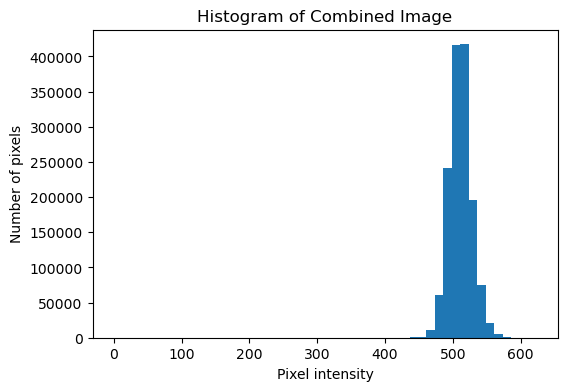

In [18]:
#3.4.2: plot histogram:
plt.figure(figsize=(6, 4))
plt.hist(combined_image.ravel(), bins=50)
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Combined Image")
plt.show()

In [19]:
center = np.median(combined_image)

vmin = center - 50
vmax = center + 50

print("vmin:", vmin)
print("vmax:", vmax)
print("difference:", vmax - vmin)

vmin: 460.0
vmax: 560.0
difference: 100.0


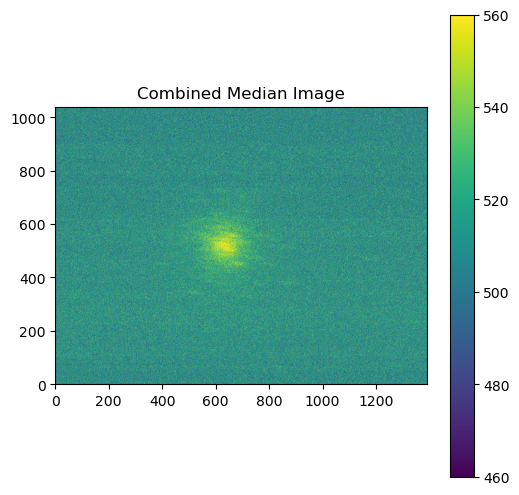

In [20]:
plt.figure(figsize=(6, 6))
plt.imshow(combined_image, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Median Image")
plt.show()

In [21]:
#Compared to the earlier individual images, the combined median image is clearer and has better contrast. 
#The bright center is more visible, and the background appears smoother because taking the median reduces random noise and outlier pixels.

In [22]:
fits.writeto("combined.fits", combined_image, overwrite=True)